# Problem Statement

#### In today’s e-commerce environment, platforms like BigBasket offer a large variety of products across multiple categories. However, not all products receive high customer ratings, which directly impacts customer satisfaction and business performance.

#### Understanding the factors that influence product ratings can help businesses improve product quality, pricing strategies, and customer experience.

#### In this project, we aim to analyze product data and build a machine learning model to predict whether a product is likely to receive a high rating (≥ 4.0) based on features such as price, category, and other attributes.

# Goal of the Project

1.Perform data cleaning and preprocessing

2.Conduct exploratory data analysis (EDA)

3.Identify patterns affecting product ratings

4.Handle imbalanced data using SMOTE

5.Build a classification model using XGBoost

6.Evaluate model performance using F1-score, precision, and recall

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv('BigBasket Products.csv')

In [5]:
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [6]:
df.tail()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori..."
27554,27555,United Dreams Go Far Deodorant,Beauty & Hygiene,Men's Grooming,United Colors Of Benetton,214.53,390.0,Men's Deodorants,4.5,The new mens fragrance from the United Dreams ...


In [7]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27555.000000,27555.000000,18929.000000
mean,13778.00000,322.514808,382.056664,3.943410
std,7954.58767,486.263116,581.730717,0.739063
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.000000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,12500.000000,12500.000000,5.000000


In [8]:
df.describe(include=['object'])

,product,category,sub_category,brand,type,description
count,27554,27555,27555,27554,27555,27440
unique,23540,11,90,2313,426,21944
top,Turmeric Powder/Arisina Pudi,Beauty & Hygiene,Skin Care,Fresho,Face Care,A brand inspired by the Greek goddess of victo...
freq,26,7867,2294,638,1508,47


In [9]:
df.isnull().sum()

,0
index,0
product,1
category,0
sub_category,0
brand,1
sale_price,0
market_price,0
type,0
rating,8626
description,115


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(27555, 10)

In [13]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

# EDA

In [14]:
num_cols = ['sale_price','market_price', 'rating']
cat_cols = ['category', 'sub_category']

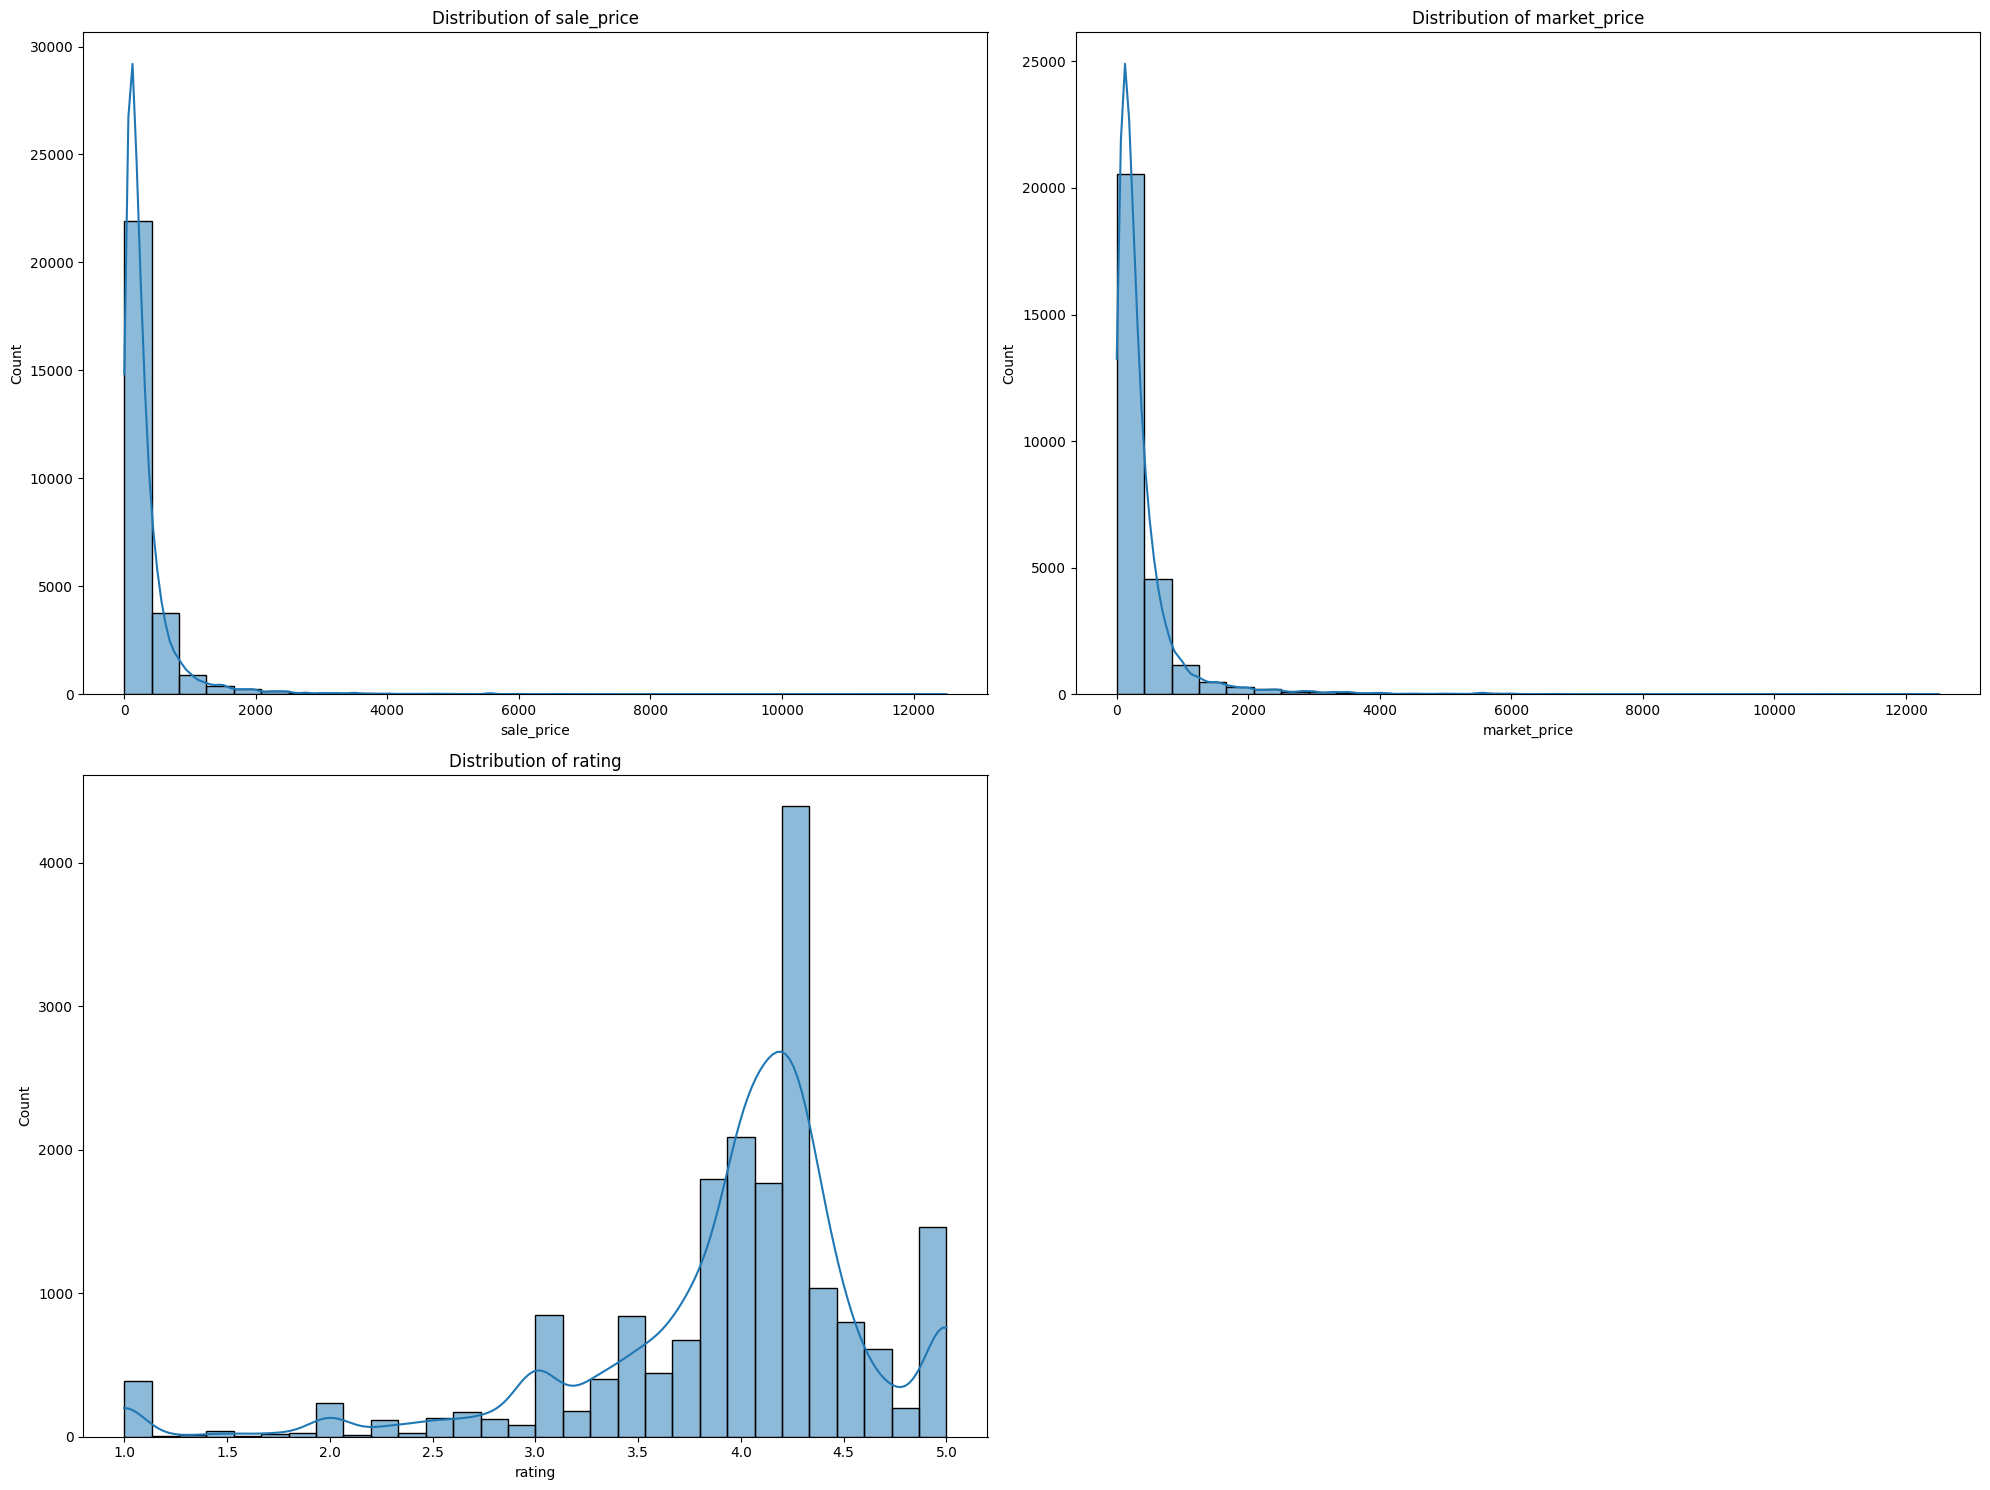

In [15]:
# Loop through numeric columns
plt.figure(figsize=(20,15), facecolor='white')
plot_number = 1

for cols in num_cols:
    if plot_number <= 3:
        ax = plt.subplot(2,2,plot_number)   # 3 rows, 2 columns grid
        sns.histplot(data=df, x=cols, bins=30, kde=True)
        plt.xticks(rotation=0)
        plt.title(f"Distribution of {cols}")
        plt.tight_layout()
        plot_number += 1

plt.show()

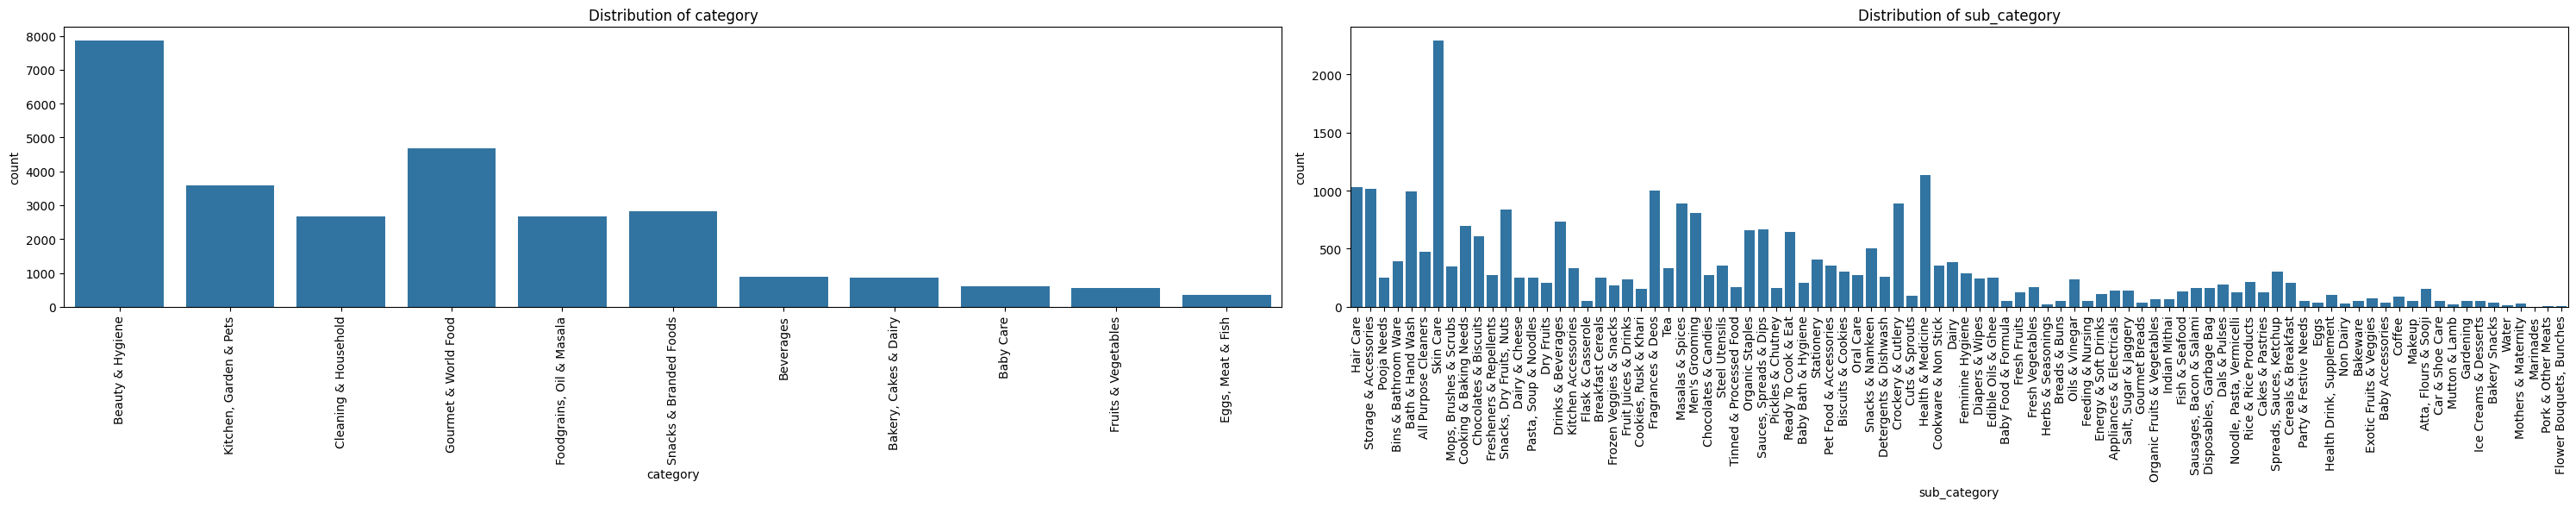

In [16]:
plt.figure(figsize=(30,15), facecolor='white')
plot_number = 1

for cols in cat_cols:
    if plot_number <= 4:
        ax = plt.subplot(3,2,plot_number)   # 3 rows, 2 columns grid
        sns.countplot(data=df, x=cols)
        plt.xticks(rotation=90)
        plt.title(f"Distribution of {cols}")
        plt.tight_layout()
        plot_number += 1

plt.show()


In [17]:
df['product'].value_counts()

,count
product,
Turmeric Powder/Arisina Pudi,26
Extra Virgin Olive Oil,15
Cow Ghee/Tuppa,14
Olive Oil - Extra Virgin,12
Soft Drink,12
...,...
"Opalware Classique Serving Bowl - Medium, Royal Irish",1
"Lavangadi Vati - Respiratory Conditions, 300mg",1
Pomegranate - Small,1


In [18]:
# Identify the top 10 brands by product count
top_10_brands = df['brand'].value_counts().nlargest(10).index

# Filter the dataframe to include only these brands
df_top10 = df[df['brand'].isin(top_10_brands)]


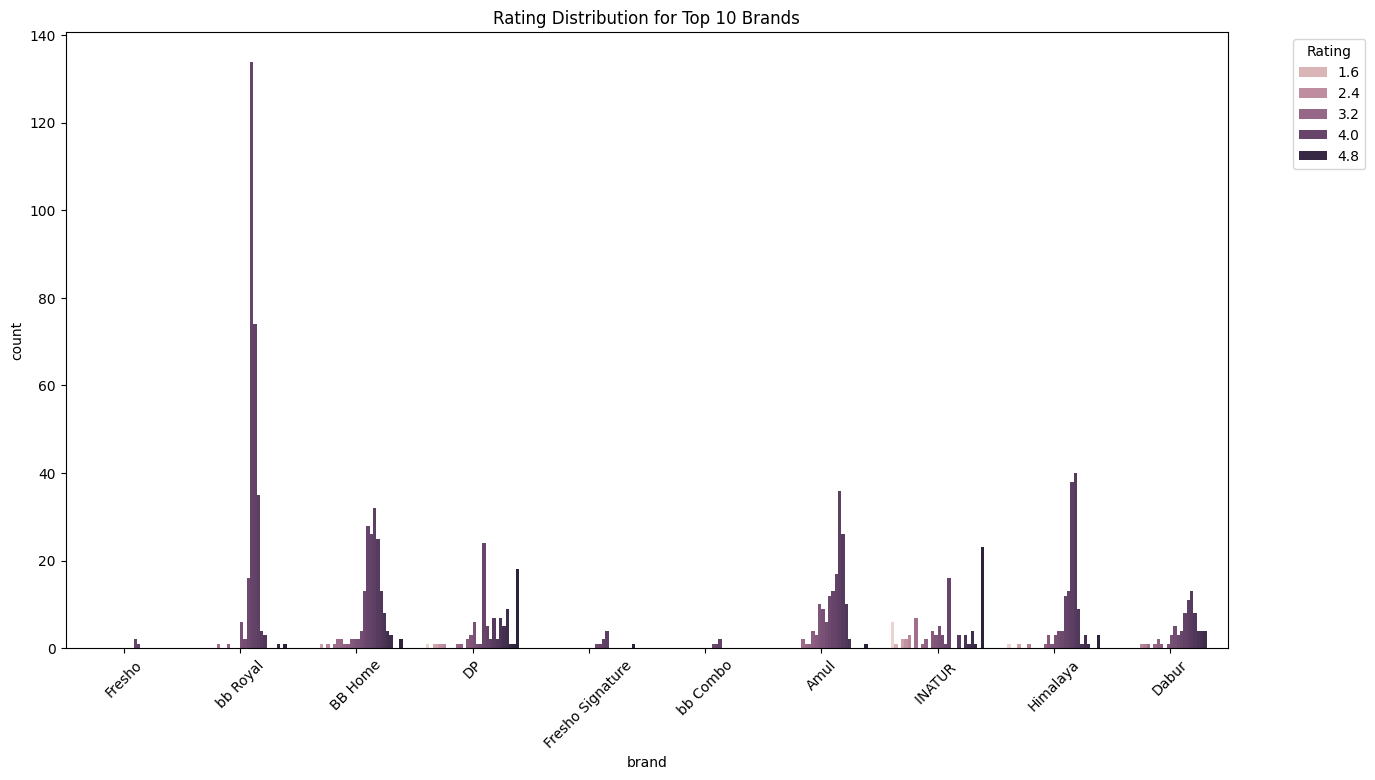

In [19]:
# Create the plot
plt.figure(figsize=(15, 8))
sns.countplot(x='brand', hue='rating', data=df_top10, order=top_10_brands)

# Improve readability
plt.title('Rating Distribution for Top 10 Brands')
plt.xticks(rotation=45)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

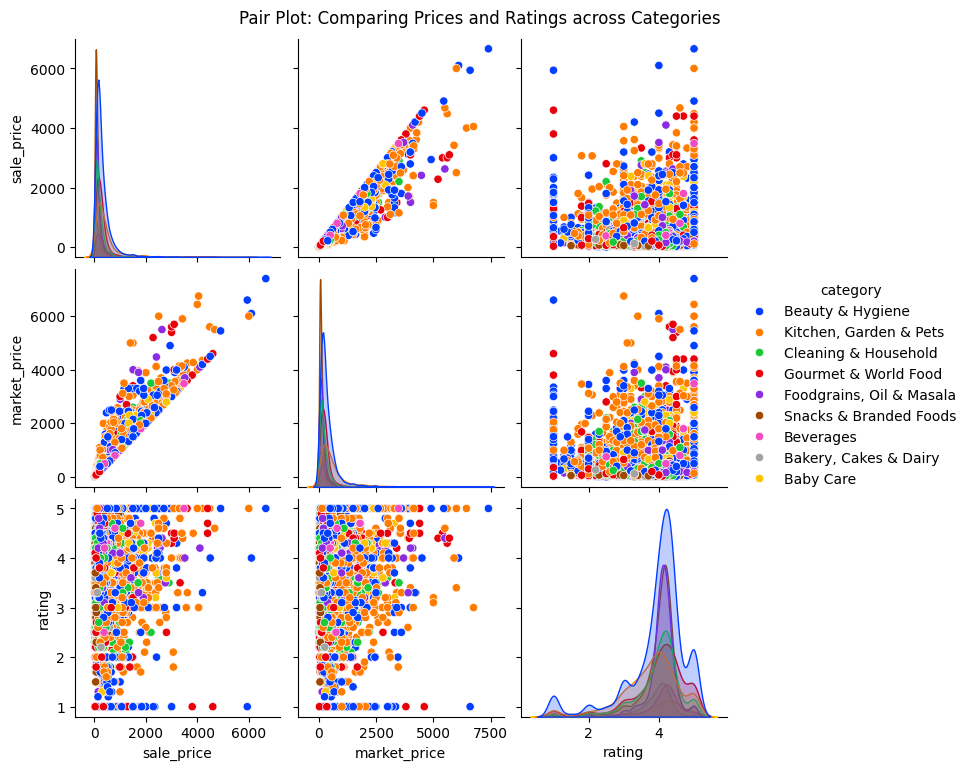

In [20]:
# We select the numerical columns and category for a clear comparison
# Dropping NaNs for a cleaner plot
plot_df = df[['sale_price', 'market_price', 'rating', 'category']].dropna()

# Create the pairplot
sns.pairplot(plot_df, hue='category', diag_kind='kde', palette='bright')
plt.suptitle('Pair Plot: Comparing Prices and Ratings across Categories', y=1.02)
plt.show()

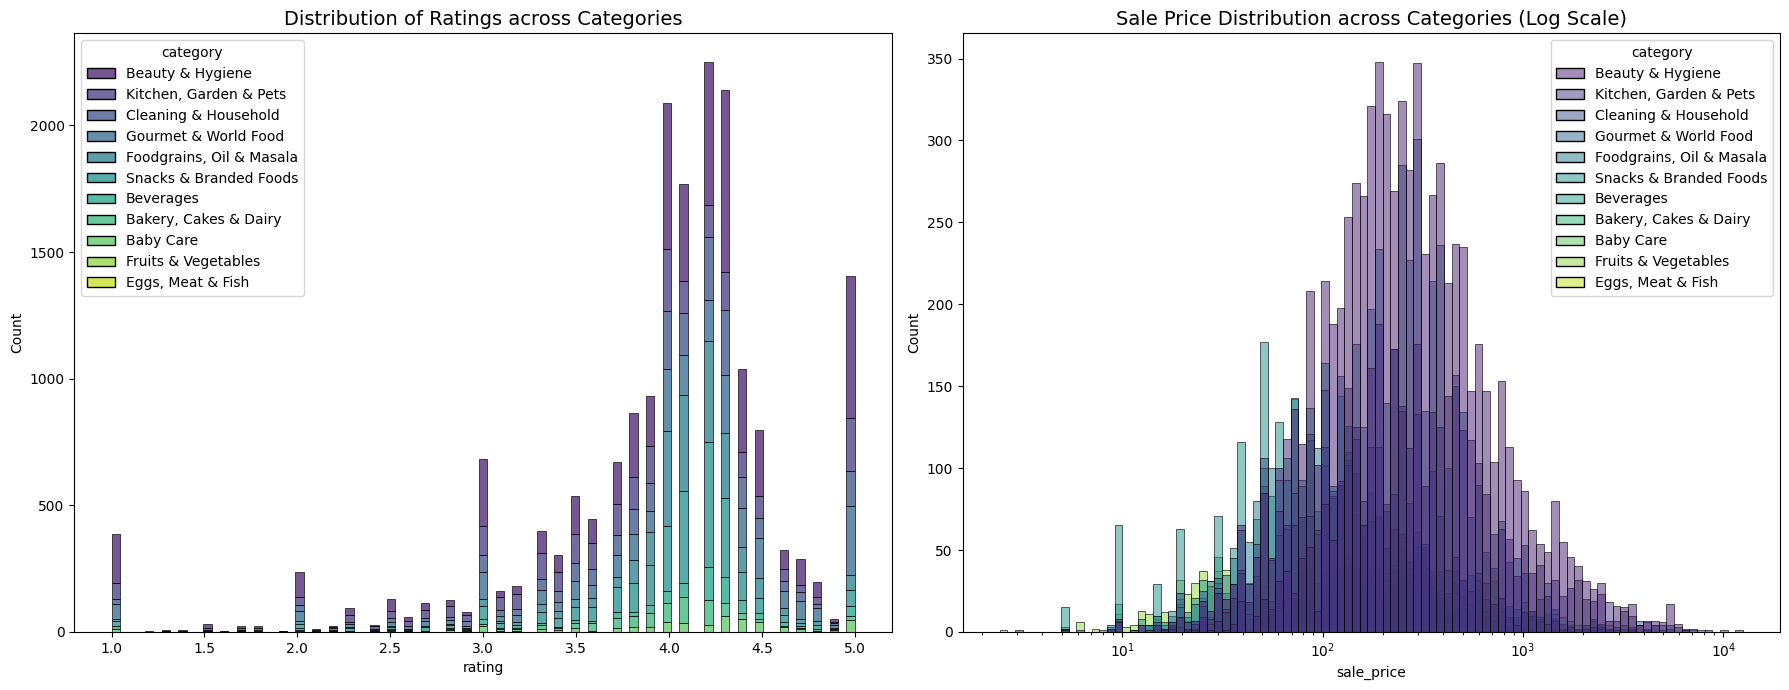

In [21]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Distribution of Ratings by Category
sns.histplot(data=df, x='rating', hue='category', multiple='stack', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Ratings across Categories', fontsize=14)

# Plot 2: Distribution of Sale Price (using log scale for better visibility)
sns.histplot(data=df, x='sale_price', hue='category', multiple='layer', ax=axes[1], log_scale=True, palette='viridis')
axes[1].set_title('Sale Price Distribution across Categories (Log Scale)', fontsize=14)

plt.tight_layout()
plt.show()

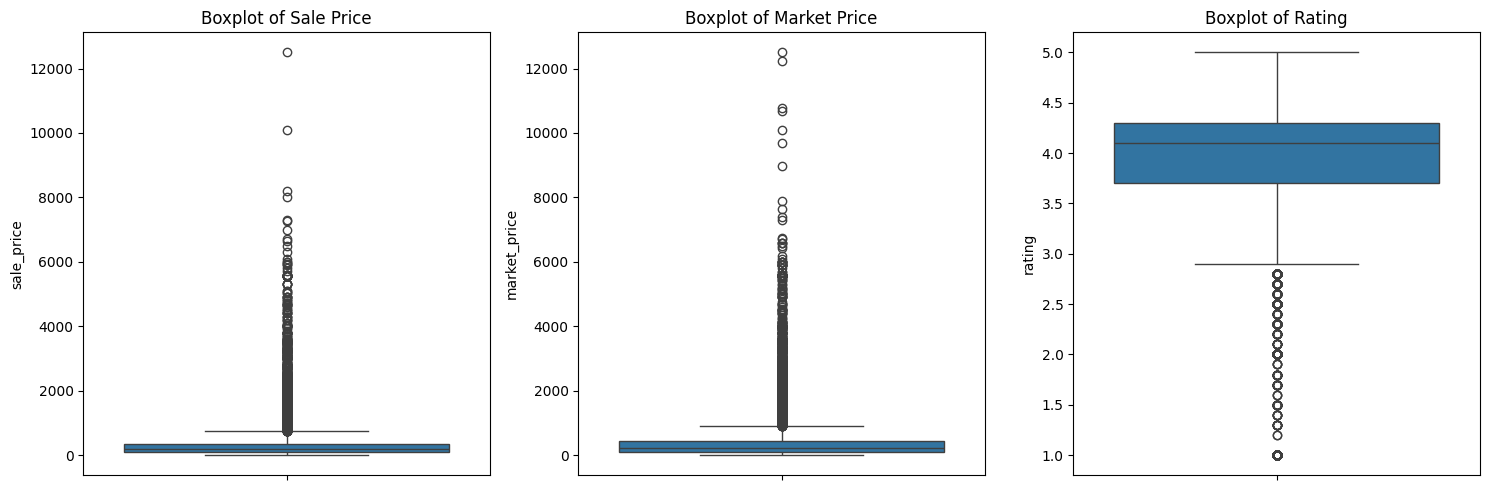

In [22]:
plt.figure(figsize=(15, 5))

# Sale Price Boxplot
plt.subplot(1, 3, 1)
sns.boxplot(y=df['sale_price'])
plt.title('Boxplot of Sale Price')

# Market Price Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(y=df['market_price'])
plt.title('Boxplot of Market Price')

# Rating Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['rating'])
plt.title('Boxplot of Rating')

plt.tight_layout()
plt.show()

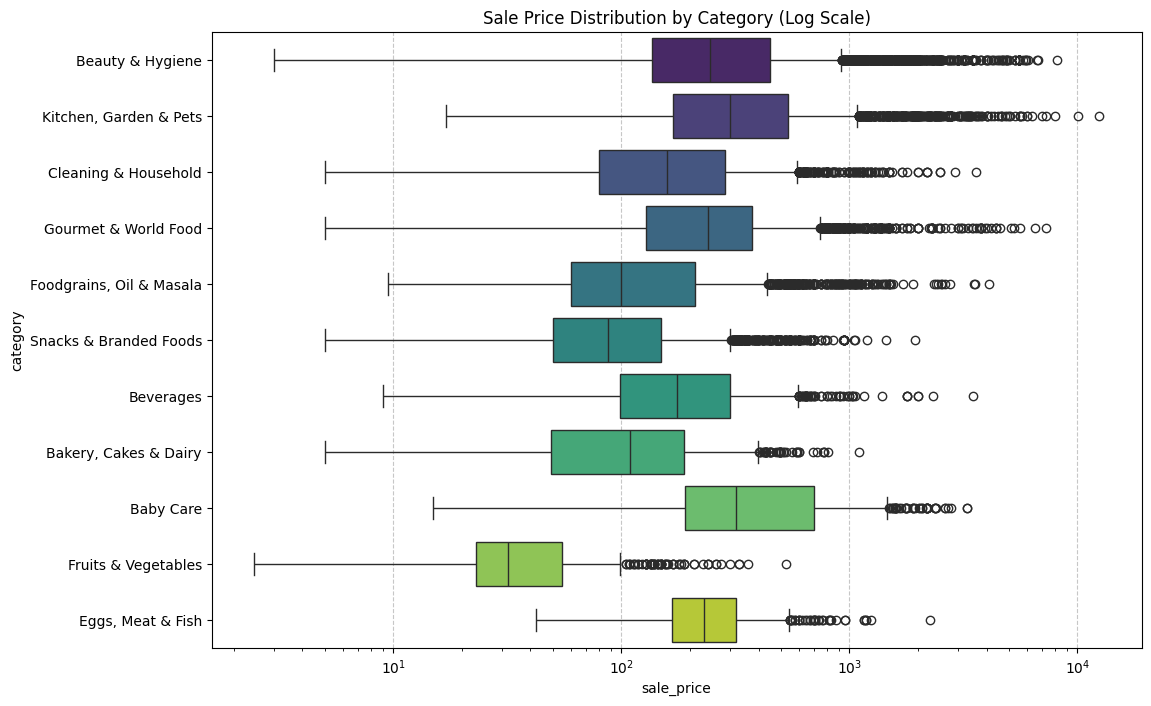

In [23]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='sale_price', y='category', data=df, palette='viridis')
plt.title('Sale Price Distribution by Category')
plt.xscale('log') # Makes it much easier to read given the price variance
plt.title('Sale Price Distribution by Category (Log Scale)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

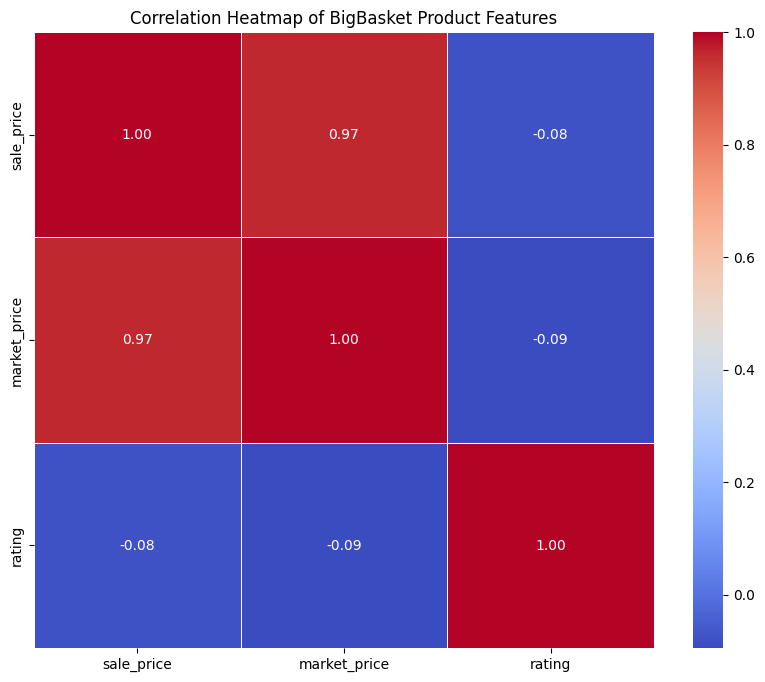

In [24]:
# 1. Select only numerical columns for correlation
numeric_df = df[['sale_price', 'market_price', 'rating']]

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of BigBasket Product Features')
plt.show()

# Insights from Graphical Representations

1. Price & Rating Distributions

Sale and market prices are right-skewed, with most products being low-priced and a few luxury outliers.

Ratings cluster around 4.0–4.5, showing strong customer satisfaction.

Outliers exist below 3.0, but they are rare.

2. Category & Subcategory Trends

Beauty & Hygiene has the highest product count (~8000), followed by Kitchen, Garden & Pets, and Cleaning & Household.

Subcategories like Storage & Accessories, Juices, Biscuits & Cookies dominate, while niche ones remain underrepresented.

Product distribution is uneven across subcategories, highlighting focus areas.

3. Brand Performance

bb Royal leads in rating volume among top brands.

Most brands cluster around higher ratings (4.0+), though some show wider spreads (e.g., Fresho, Amul).

Customer perception is generally positive across brands.

4. Relationships Between Variables

Sale price and market price show a strong linear correlation (0.97).

Ratings have a weak negative correlation with prices (-0.08 to -0.09), meaning higher prices don’t guarantee better ratings.

Categories form distinct clusters in pair plots, reflecting unique pricing and rating behaviors.

5. Category-wise Insights

Ratings across categories are consistently high (~4.0).

Sale prices (on log scale) show most products are low-priced, but Gourmet & World Food and Beverages have wider spreads, indicating premium ranges.

Fruits & Vegetables remain tightly clustered at the lower end.

6. Boxplot Observations

Sale and market prices: dense clusters at the bottom with extreme outliers up to ~12,000.

Ratings: median around 4.0, with occasional poor reviews pulling down outliers.

Variability in prices is much higher than in ratings.

7. Correlation Heatmap

Sale Price vs Market Price: Very high correlation (0.97), confirming strong alignment.

Rating vs Prices: Weak negative correlation (-0.08 to -0.09), meaning higher prices don’t necessarily lead to better ratings.

Overall Insight: Customer satisfaction (ratings) is largely independent of product pricing.

# Data Pre Processing

In [25]:
df_clean = df.copy()

In [26]:
df_clean

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.00,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.00,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.00,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.00,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.00,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...
...,...,...,...,...,...,...,...,...,...,...
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori..."


In [27]:
df_clean.isnull().sum()

,0
index,0
product,1
category,0
sub_category,0
brand,1
sale_price,0
market_price,0
type,0
rating,8626
description,115


In [28]:
df_clean['rating'] = df_clean['rating'].fillna(df_clean.groupby('category')['rating'].transform('mean'))
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].median())

In [29]:
df_clean.dropna(subset=['product', 'brand', 'description'], inplace=True)

In [30]:
df_clean.drop_duplicates(inplace=True)

In [31]:
le_sub = LabelEncoder()
df_clean['sub_cat_encoded'] = le_sub.fit_transform(df_clean['sub_category'])

In [32]:
df_clean.shape

(27439, 11)

## Insights Of Data-PreProcessing

Safe Copy

Created df_clean = df.copy() to protect raw data.

Missing Value Handling

rating: Filled first with category mean, then with overall median → ensures ratings stay realistic and consistent.

Dropped rows missing critical info (product, brand, description) → keeps dataset reliable for analysis.

Duplicates Removed

Ensures no repeated records, avoids bias in training.

Categorical Encoding

Used LabelEncoder for sub_category → converted text into numbers for ML models.

Customer Trust: By filling ratings smartly, you avoid misleading averages and keep product evaluation fair.

Brand & Product Integrity: Dropping incomplete records ensures only valid products are analyzed, which strengthens business decisions.

Operational Efficiency: Removing duplicates prevents double counting in sales or inventory reports.

Market Insights: Encoding categories allows segmentation (e.g., which
sub‑categories drive high ratings or sales).

# Feature Engineering

In [33]:
df_clean['is_high_rated'] = (df_clean['rating'] >= 4.0).astype(int)

In [34]:
X = df_clean[['market_price', 'sale_price', 'sub_cat_encoded']]
y = df_clean['is_high_rated']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res_scaled, y_train_res_scaled = smote.fit_resample(
    X_train_scaled, y_train
)

# Feature Engennering

High‑Rated Flag

is_high_rated = (rating >= 4.0) → Binary feature (1 = high rated, 0 = low rated).

 Simplifies the problem into a clear classification task.

Selected Predictors

Features: market_price, sale_price, sub_cat_encoded.

Target: is_high_rated.

 Focuses on price and category signals to predict product quality perception.

Train‑Test Split

80% training, 20% testing → ensures fair evaluation.

Feature Scaling

StandardScaler applied → keeps features on the same scale, important for algorithms like KNN, SVM, Logistic Regression.

SMOTE Oversampling

Balanced the dataset by generating synthetic samples for the minority class (low‑rated products).

 Prevents bias toward majority class, improves recall for underrepresented cases.

 Customer Experience: By flagging high‑rated products, businesses can highlight them in promotions, recommendations, or premium listings.

Pricing Strategy: Linking ratings with sale vs. market price helps identify if discounts influence customer satisfaction.

Category Insights: Encoding sub‑categories allows analysis of which product types consistently achieve high ratings.

Fairness in Decisions: SMOTE ensures low‑rated products aren’t ignored, giving balanced insights into both strengths and weaknesses.

A balanced classification pipeline that connects product pricing and category signals to customer satisfaction outcomes.

# Model Bulding

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.ensemble import GradientBoostingClassifier

In [39]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_res_scaled, y_train_res_scaled)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
# Evaluation
y_pred = log_reg.predict(X_test_scaled)
print("Logistic Regression F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression F1: 0.6258524980174465
              precision    recall  f1-score   support

           0       0.65      0.40      0.49      2897
           1       0.53      0.76      0.63      2591

    accuracy                           0.57      5488
   macro avg       0.59      0.58      0.56      5488
weighted avg       0.59      0.57      0.56      5488



In [41]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res_scaled, y_train_res_scaled)


KNeighborsClassifier()

In [42]:
# Prediction
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("KNN F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

KNN F1: 0.6440030557677616
              precision    recall  f1-score   support

           0       0.68      0.67      0.68      2897
           1       0.64      0.65      0.64      2591

    accuracy                           0.66      5488
   macro avg       0.66      0.66      0.66      5488
weighted avg       0.66      0.66      0.66      5488



In [43]:
# Model
svm = SVC(probability=True)
svm.fit(X_train_res_scaled, y_train_res_scaled)

SVC(probability=True)

In [44]:
# Prediction
y_pred = svm.predict(X_test_scaled)

# Evaluation
print("SVM F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SVM F1: 0.585814038956266
              precision    recall  f1-score   support

           0       0.62      0.57      0.59      2897
           1       0.56      0.62      0.59      2591

    accuracy                           0.59      5488
   macro avg       0.59      0.59      0.59      5488
weighted avg       0.59      0.59      0.59      5488



In [45]:
# SMOTE (on original data)
smote_tree = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [47]:
y_pred_rf = rf.predict(X_test)

print("Random Forest F1:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest F1: 0.6624905087319666
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      2897
           1       0.65      0.67      0.66      2591

    accuracy                           0.68      5488
   macro avg       0.68      0.68      0.68      5488
weighted avg       0.68      0.68      0.68      5488



In [48]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost F1:", f1_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost F1: 0.6976483762597985
              precision    recall  f1-score   support

           0       0.73      0.69      0.71      2897
           1       0.68      0.72      0.70      2591

    accuracy                           0.70      5488
   macro avg       0.71      0.71      0.70      5488
weighted avg       0.71      0.70      0.71      5488



In [50]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_res, y_train_res)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [51]:
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting F1:", f1_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting F1: 0.686782673084043
              precision    recall  f1-score   support

           0       0.73      0.67      0.70      2897
           1       0.66      0.72      0.69      2591

    accuracy                           0.69      5488
   macro avg       0.69      0.69      0.69      5488
weighted avg       0.69      0.69      0.69      5488



# Insights of Models

1. Logistic Regression (F1 ≈ 0.62) → Weak baseline. It struggles to balance precision and recall, especially for class 0 (low‑rated products).

2. KNN (F1 ≈ 0.64) → Better than Logistic Regression. Captures local patterns   well, but runtime can be slow on large datasets.

3. SVM (F1 ≈ 0.59) → Moderate performance. Not as strong here, possibly due to feature scaling and dataset complexity.

4. Random Forest (F1 ≈ 0.66) → Solid improvement. Handles non‑linear relationships and reduces overfitting.

5. XGBoost (F1 ≈ 0.70) → Best performer. Strong balance of precision and recall, learns complex patterns effectively.

6. Gradient Boosting (F1 ≈ 0.69) → Close to XGBoost, but slightly less efficient.

7. Customer Satisfaction Prediction: Models can forecast if a product will be rated “good” (≥4.0) or “poor.”
This helps companies identify risky products before launch.

8. Marketing & Inventory Strategy:

High‑rated predictions → Promote aggressively, highlight in campaigns.

Low‑rated predictions → Reconsider stock, improve quality, or adjust pricing.

9. Operational Efficiency → Balanced models (XGBoost/Random Forest) ensure both satisfied and dissatisfied customers are represented.
This prevents blind spots in decision‑making.

# Hyper-Perameter Tunning With RandomizedSearchCV

In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [53]:
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [54]:
# 4. Results
print(f"Best Parameters: {xgb_search.best_params_}")
best_xgb = xgb_search.best_estimator_

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [55]:
# 5. Final Evaluation
y_pred_tuned = best_xgb.predict(X_test)
print("\n--- TUNED XGBOOST REPORT ---")
print(classification_report(y_test, y_pred_tuned))


--- TUNED XGBOOST REPORT ---
              precision    recall  f1-score   support

           0       0.74      0.69      0.71      2897
           1       0.67      0.73      0.70      2591

    accuracy                           0.71      5488
   macro avg       0.71      0.71      0.71      5488
weighted avg       0.71      0.71      0.71      5488



In [56]:
rf = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

In [ ]:
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Random Forest Tuned Report")
print(classification_report(y_test, y_pred_best_rf))

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    param_grid=param_grid_gb,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

gb_grid.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [60]:
best_gb = gb_grid.best_estimator_

# Predict using best model
y_pred_gb = best_gb.predict(X_test)

print("--- GRADIENT BOOSTING REPORT ---")
print(classification_report(y_test, y_pred_gb))

--- GRADIENT BOOSTING REPORT ---
              precision    recall  f1-score   support

           0       0.74      0.68      0.71      2897
           1       0.67      0.73      0.70      2591

    accuracy                           0.70      5488
   macro avg       0.70      0.70      0.70      5488
weighted avg       0.71      0.70      0.70      5488



## Insights of Hyper-perameter Tunning

1. XGBoost (RandomizedSearchCV)

Best parameters: n_estimators=200, max_depth=5, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8.

Performance: Accuracy ~71%, F1 ~0.70.

Balanced precision and recall → strong generalization.

2. Random Forest (RandomizedSearchCV)

Tuned parameters improved stability.

Performance: Accuracy ~68%, F1 ~0.67.

Good, but slightly weaker than boosting methods.

3. Gradient Boosting (GridSearchCV)

Best parameters: n_estimators=200, learning_rate=0.1, max_depth=3–5.

Performance: Accuracy ~70%, F1 ~0.70.

Very close to XGBoost, but less efficient in training.

In [61]:
from sklearn.metrics import f1_score

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
print("XGBoost F1:", f1_score(y_test, y_pred_xgb))

# Random Forest
y_pred_rf = best_rf.predict(X_test)
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

# Gradient Boost
y_pred_gb = best_gb.predict(X_test)
print("Gradient Boost F1:", f1_score(y_test, y_pred_gb))

XGBoost F1: 0.7010385756676558
Random Forest F1: 0.666539996199886
Gradient Boost F1: 0.6985539488320356


Improved Prediction Reliability → Hyperparameter tuning raised performance from ~66% F1 (untuned RF) to ~70% F1 (tuned XGBoost/GB).
This means fewer misclassifications of customer satisfaction, directly improving trust in insights.

Customer Strategy →

High‑rated predictions → Products to promote, bundle, or highlight in campaigns.

Low‑rated predictions → Products to improve, discount, or phase out.

Operational Efficiency →

XGBoost and Gradient Boosting provide better recall for dissatisfied customers, ensuring risks are flagged early.

Random Forest remains a stable fallback model with lower complexity.

In [62]:
import joblib
joblib.dump(best_xgb, 'xgb_model.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')
# Save label encoder
joblib.dump(le_sub, 'label_encoder_subcat.pkl')
# (Optional but good for explanation)
joblib.dump(xgb_search.best_params_, 'best_params.pkl')

['best_params.pkl']